## Code

  Abhishek V Ammanagi  |  2023BCSE07AED500
  Experiment 6: LSTM Autoencoder Anomaly Detection
Train: (2970, 30, 1) | Test: (570, 30, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.3459 - val_loss: 0.2872
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2825 - val_loss: 0.2795
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2593 - val_loss: 0.2150
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1863 - val_loss: 0.1762
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1177 - val_loss: 0.0843
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0760 - val_loss: 0.0563
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0587 - val_loss: 0.0545
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0460 - val_loss: 0.0474
Epoch 9/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0407 - val_loss: 0.0414
Epoch 10/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0360 - val_loss: 0.0418
Epoch 11/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0333 - val_loss: 0.0297
Epoch 12/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

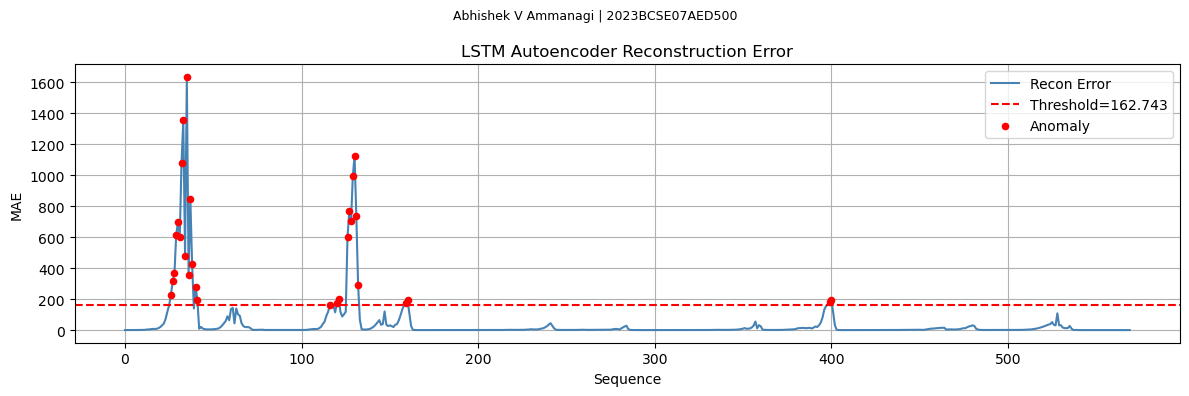

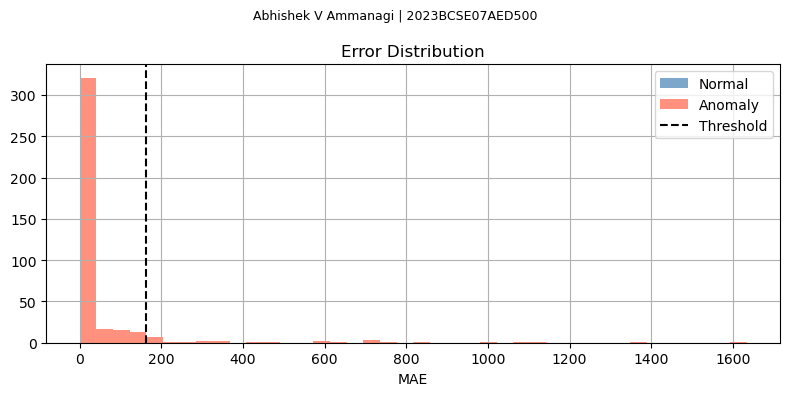

Abhishek V Ammanagi | 2023BCSE07AED500


In [1]:
# Experiment 6 – LSTM Autoencoder Anomaly Detection
# Abhishek V Ammanagi | 2023BCSE07AED500

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

print("=" * 55)
print("  Abhishek V Ammanagi  |  2023BCSE07AED500")
print("  Experiment 6: LSTM Autoencoder Anomaly Detection")
print("=" * 55)

np.random.seed(42)
SEQ_LEN = 30

normal = np.sin(np.linspace(0,200*np.pi,3000)) +          np.random.normal(0,0.05,3000)
test   = np.sin(np.linspace(0,40*np.pi,600))   +          np.random.normal(0,0.05,600)
labels = np.zeros(600)
for idx in np.random.choice(range(SEQ_LEN,570),20,replace=False):
    test[idx:idx+5]   += np.random.uniform(3,5,5)
    labels[idx:idx+5]  = 1

sc      = MinMaxScaler()
n_norm  = sc.fit_transform(normal.reshape(-1,1)).flatten()
n_test  = sc.transform(test.reshape(-1,1)).flatten()

mk = lambda d: np.array([d[i:i+SEQ_LEN] for i in range(len(d)-SEQ_LEN)])
X_train = mk(n_norm).reshape(-1,SEQ_LEN,1)
X_test  = mk(n_test).reshape(-1,SEQ_LEN,1)
y_seq   = np.array([1 if labels[i:i+SEQ_LEN].max()>0
                    else 0 for i in range(len(labels)-SEQ_LEN)])
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

inp     = Input(shape=(SEQ_LEN,1))
enc     = layers.LSTM(64, activation='relu')(inp)
rep     = layers.RepeatVector(SEQ_LEN)(enc)
dec     = layers.LSTM(64, activation='relu', return_sequences=True)(rep)
out     = layers.TimeDistributed(layers.Dense(1))(dec)
ae      = Model(inp, out)
ae.compile(optimizer='adam', loss='mae')
ae.summary()

history = ae.fit(X_train, X_train, epochs=20, batch_size=64,
                 validation_split=0.1, verbose=1)

recon = ae.predict(X_test)
err   = np.mean(np.abs(recon - X_test), axis=(1,2))
thr   = np.percentile(err, 95)
ypred = (err > thr).astype(int)

print(f"\nThreshold (95th pct): {thr:.4f}")
print(classification_report(y_seq, ypred,
      target_names=['Normal','Anomaly']))

plt.figure(figsize=(12,4))
plt.plot(err, color='steelblue', label='Recon Error')
plt.axhline(thr, color='red', linestyle='--',
            label=f'Threshold={thr:.3f}')
plt.scatter(np.where(ypred==1)[0], err[ypred==1],
            color='red', s=20, zorder=5, label='Anomaly')
plt.title('LSTM Autoencoder Reconstruction Error')
plt.xlabel('Sequence'); plt.ylabel('MAE')
plt.legend(); plt.grid(True)
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500", fontsize=9)
plt.tight_layout(); plt.savefig('exp6_err.png',dpi=300); plt.show()

plt.figure(figsize=(8,4))
plt.hist(err[y_seq==0],bins=40,alpha=0.7,label='Normal',color='steelblue')
plt.hist(err[y_seq==1],bins=40,alpha=0.7,label='Anomaly',color='tomato')
plt.axvline(thr,color='black',linestyle='--',label='Threshold')
plt.title('Error Distribution'); plt.xlabel('MAE')
plt.legend(); plt.grid(True)
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500", fontsize=9)
plt.tight_layout(); plt.savefig('exp6_dist.png',dpi=300); plt.show()
print("Abhishek V Ammanagi | 2023BCSE07AED500")


## Result
_Run the cell above and paste your observations here._